# CAMM Hackathon #10: STEM Image Restoration

STEM image credits: Austin Houston


In [88]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import json

In [4]:
!gdown https://drive.google.com/file/d/14N5Vg7Baqj2OdvgTD1l9oaWWvNvPCpYs/view?usp=drive_link --fuzzy

Downloading...
From: https://drive.google.com/uc?id=14N5Vg7Baqj2OdvgTD1l9oaWWvNvPCpYs
To: /content/graphene_2.h5
100% 17.1M/17.1M [00:00<00:00, 132MB/s]


In [28]:
!gdown https://drive.google.com/file/d/1IB2Au4Dh7iNZCeOmj1dmaGB2JOIFAxoN/view?usp=drive_link --fuzzy

Downloading...
From: https://drive.google.com/uc?id=1IB2Au4Dh7iNZCeOmj1dmaGB2JOIFAxoN
To: /content/HAADF_21.h5
100% 4.53M/4.53M [00:00<00:00, 224MB/s]


In [5]:
#@title h5 load
def save_dict_to_hdf5(file_path, data_dict):
    with h5py.File(file_path, 'w') as f:
        _recursively_save(f, data_dict)

def _recursively_save(group, data):
    if isinstance(data, dict):
        for key, value in data.items():
            subgroup = group.create_group(str(key))
            _recursively_save(subgroup, value)

    elif isinstance(data, list):
        # Turn list into group with numerical keys
        for i, item in enumerate(data):
            subgroup = group.create_group(str(i))
            _recursively_save(subgroup, item)

    elif isinstance(data, np.ndarray):
        if data.dtype == object:
            # convert each element to string (json)
            data_as_str = np.array([json.dumps(x) for x in data], dtype='S256')
            group.create_dataset('value', data=data_as_str)
        else:
            group.create_dataset('value', data=data)

    elif isinstance(data, (int, float, np.int_, np.float_)):
        group.create_dataset('value', data=data)

    elif data is None:
        group.attrs['value'] = 'None'

    else:
        # Fallback: convert unknown object to JSON string
        group.create_dataset('value', data=json.dumps(data))


def load_hdf5_to_dict(file_path):
    with h5py.File(file_path, "r") as f:
        return _load_item(f)



def _load_item(obj):
    """
    Load any HDF5 object (Group or Dataset) and reconstruct Python object.
    """
    # ---------------------------------------------------------
    # CASE 1 — HDF5 GROUP  (recursive dict or list)
    # ---------------------------------------------------------
    if isinstance(obj, h5py.Group):
        keys = list(obj.keys())

        # Empty group → return None or empty dict
        if len(keys) == 0 and "value" not in obj.attrs:
            return {}

        # Detect list: all keys are integers
        if all(k.isdigit() for k in keys):
            lst = []
            for k in sorted(keys, key=lambda x: int(x)):
                lst.append(_load_item(obj[k]))
            return lst

        # Regular dictionary
        out = {}
        for k in keys:
            out[k] = _load_item(obj[k])

        # Special case: group representing None
        if "value" in obj.attrs and obj.attrs["value"] == "None":
            return None

        return out

    # ---------------------------------------------------------
    # CASE 2 — HDF5 DATASET  (arrays / scalars / strings)
    # ---------------------------------------------------------
    elif isinstance(obj, h5py.Dataset):
        data = obj[()]

        # Scalar
        if np.isscalar(data):
            return data

        # Byte strings → JSON or text
        if isinstance(data, (bytes, np.bytes_)):
            try:
                return json.loads(data.decode())
            except:
                return data.decode()

        # Array of byte strings
        if data.dtype.kind == "S":
            try:
                return [json.loads(x.decode()) for x in data]
            except:
                return [x.decode() for x in data]

        # Normal numpy array
        return data

    # ---------------------------------------------------------
    # CASE 3 — Attributes marking None
    # ---------------------------------------------------------
    else:
        raise ValueError("Unknown HDF5 object type:", obj)


def get_arr(runs, key):
    """
    Extract numpy array from runs[key], automatically handling nested {'value': array}.
    """
    val = runs[key]
    if isinstance(val, dict) and "value" in val:
        return np.asarray(val["value"])
    return np.asarray(val)



In [94]:
#@title masking functions
from scipy.ndimage import binary_dilation
from skimage.draw import line as draw_line

def mask_below_line(im, row=None, frac=0.6, above=True):
    """
    Mask all pixels below (or above) a horizontal threshold row.

    Parameters
    ----------
    im : 2D array
    row   : int, absolute row index. Defaults to frac * H.
    frac  : float, fraction of height for the cut if row is None.
    above : bool, if True mask everything above the line instead.

    Returns
    -------
    mask : bool ndarray (H, W)
    """
    H, W = im.shape
    if row is None:
        row = int(frac * H)
    mask = np.zeros((H, W), dtype=bool)
    if above:
        mask[:row, :] = True
    else:
        mask[row:, :] = True
    return mask

def mask_lakes(im, n_lakes=10, size_range=(10, 220), aspect_range=(0.5, 4.0),
               roughness=0.8, n_harmonics=34, seed=None):
    """
    Lake regions with ragged / torn borders, arranged in a loose cluster.

    The border is a polar curve whose radius is modulated by a sum of random
    sinusoids, producing irregular, non-repeating jagged edges.

    Parameters
    ----------
    im : 2D array
    n_lakes      : number of lakes
    size_range   : (min, max) semi-major axis in pixels
    aspect_range : (min, max) aspect ratio (semi-major / semi-minor)
    roughness    : 0 = smooth ellipse, 1 = very jagged (good range: 0.2–0.6)
    n_harmonics  : number of sinusoidal harmonics added to the border
    seed         : RNG seed

    Returns
    -------
    mask : bool ndarray (H, W)
    """
    rng = np.random.default_rng(seed)
    H, W = im.shape
    mask = np.zeros((H, W), dtype=bool)

    # loose cluster centre
    cy_c = rng.integers(H // 4, 3 * H // 4)
    cx_c = rng.integers(W // 4, 3 * W // 4)
    spread = max(H, W) // 4

    yy, xx = np.mgrid[:H, :W]

    for _ in range(n_lakes):
        cy = int(np.clip(rng.normal(cy_c, spread), 0, H - 1))
        cx = int(np.clip(rng.normal(cx_c, spread), 0, W - 1))
        a = rng.integers(*size_range)           # semi-major
        aspect = rng.uniform(*aspect_range)
        b = max(1, int(a / aspect))             # semi-minor
        angle = rng.uniform(0, np.pi)

        # rotate coordinates
        dy = yy - cy
        dx = xx - cx
        cos_a, sin_a = np.cos(angle), np.sin(angle)
        u = cos_a * dx + sin_a * dy             # along major axis
        v = -sin_a * dx + cos_a * dy            # along minor axis

        # polar angle of every pixel relative to lake centre
        theta = np.arctan2(v, u)

        # ragged radius envelope: 1 + sum of random harmonics
        freqs = rng.integers(2, n_harmonics + 2, size=n_harmonics)
        amps  = rng.uniform(0, roughness / n_harmonics, size=n_harmonics)
        phases = rng.uniform(0, 2 * np.pi, size=n_harmonics)
        envelope = 1.0 + sum(
            amp * np.sin(freq * theta + phase)
            for amp, freq, phase in zip(amps, freqs, phases)
        )

        # pixel is inside if its normalised ellipse distance < ragged envelope
        dist = np.sqrt((u / a) ** 2 + (v / b) ** 2)
        mask |= dist <= envelope

    return ~mask

def mask_lines(im, n_lines=80, thickness=4, orientation="horizontal", seed=None):
    """
    Thin random straight lines across the image (horizontal, vertical, or diagonal).

    Parameters
    ----------
    im : 2D array
    n_lines     : number of lines
    thickness   : line width in pixels (via dilation)
    orientation : "horizontal" | "vertical" | "diagonal" | "mixed"
    seed        : RNG seed

    Returns
    -------
    mask : bool ndarray (H, W)
    """
    rng = np.random.default_rng(seed)
    H, W = im.shape
    mask = np.zeros((H, W), dtype=bool)

    orientations = ["horizontal", "vertical", "diagonal"]

    for _ in range(n_lines):
        if orientation == "mixed":
            ort = rng.choice(orientations)
        else:
            ort = orientation

        if ort == "horizontal":
            r = rng.integers(0, H)
            mask[r, :] = True
        elif ort == "vertical":
            c = rng.integers(0, W)
            mask[:, c] = True
        else:  # diagonal
            r0, c0 = rng.integers(0, H), rng.integers(0, W)
            r1, c1 = rng.integers(0, H), rng.integers(0, W)
            rr, cc = draw_line(r0, c0, r1, c1)
            valid = (rr >= 0) & (rr < H) & (cc >= 0) & (cc < W)
            mask[rr[valid], cc[valid]] = True

    if thickness > 1:
        struct = np.ones((thickness, thickness), dtype=bool)
        mask = binary_dilation(mask, structure=struct)

    return ~mask

def mask_small_blobs(im, n_blobs=300, size_range=(1, 24), seed=None):
    """
    Many tiny blobs simulating dead-pixel clusters or dust on the detector.

    Parameters
    ----------
    im      : 2D array
    n_blobs    : number of small blobs
    size_range : (min_r, max_r) radius in pixels
    seed       : RNG seed

    Returns
    -------
    mask : bool ndarray (H, W)
    """
    rng = np.random.default_rng(seed)
    H, W = im.shape
    mask = np.zeros((H, W), dtype=bool)

    yy, xx = np.ogrid[:H, :W]

    for _ in range(n_blobs):
        cy = rng.integers(0, H)
        cx = rng.integers(0, W)
        r = rng.integers(*size_range)
        mask |= (yy - cy) ** 2 + (xx - cx) ** 2 <= r ** 2

    return ~mask

In [34]:
data = load_hdf5_to_dict('/content/graphene_2.h5')
data_more = load_hdf5_to_dict('/content/HAADF_21.h5')

im0 = data['Measurement_000']['Channel_000']['HAADF']['HAADF'][:1000, :1000]
im1 = data['Measurement_001']['Channel_000']['HAADF']['HAADF'][:1000, :1000]
im2 = data['Measurement_001']['Channel_000']['HAADF']['HAADF'][:1000, -1000:]
im3 = data_more['Measurement_000']['Channel_000']['HAADF']['HAADF']

ims = [im0, im1, im2, im3]

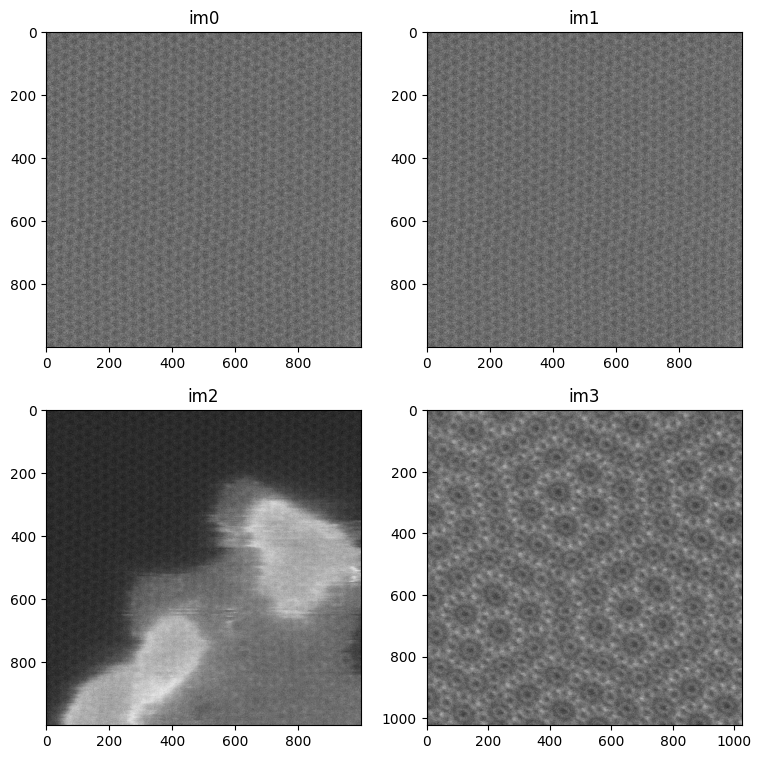

In [40]:
fig, axes = plt.subplots(2,2, figsize=(9,9))

ax = axes.flatten()

for i, _ in enumerate(ax):
  _.imshow(ims[i], cmap='gray')
  _.set_title(f'im{i}')

Text(0.5, 1.0, 'mask_small_blobs()')

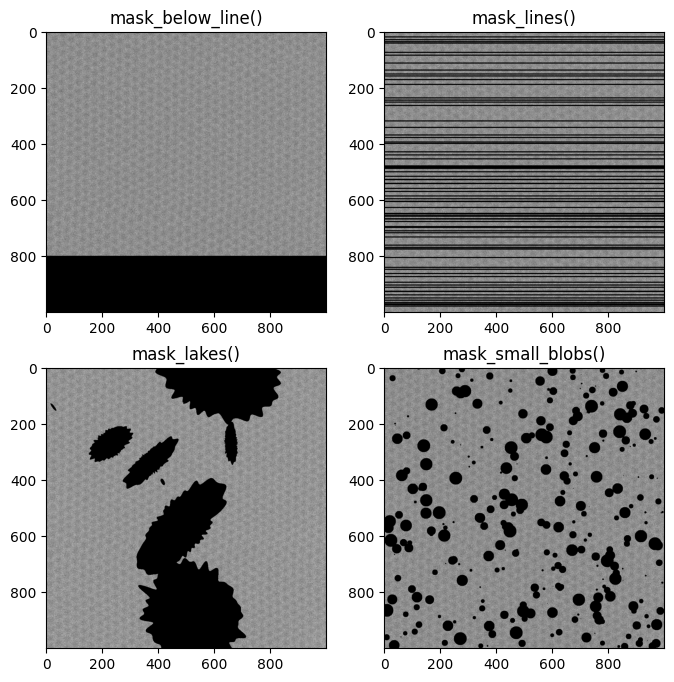

In [93]:
fig, ax = plt.subplots(2,2, figsize=(8,8))


ax[0,0].imshow(mask_below_line(im0, frac=0.8)*im0, cmap='gray')
ax[0,0].set_title('mask_below_line()')

ax[0,1].imshow(mask_lines(im0)*im0, cmap='gray')
ax[0,1].set_title('mask_lines()')

ax[1,0].imshow(mask_lakes(im0)*im0, cmap='gray')
ax[1,0].set_title('mask_lakes()')

ax[1,1].imshow(mask_small_blobs(im0)*im0, cmap='gray')
ax[1,1].set_title('mask_small_blobs()')


# Given a 2D microscopy intensity array and a binary loss mask, reconstruct missing regions and estimate prediction uncertainty

In [79]:
#your code